<a href="https://colab.research.google.com/github/perrymason-droid/ores5160-2026/blob/main/week07/Intro_to_Pandas_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Here is the data for this esercise:**
Download the following file and upload it using the code block above. Then rename the long file name to airquality.csv.

https://drive.google.com/file/d/1SBD8R6jl5_ycl3X7hulrlHpqR-w3i__a/view?usp=drive_link

The information below is for licensing compliance purposes per dataset owner instructions.

License: https://creativecommons.org/licenses/by-sa/4.0/.
Data Source: https://openaq.org/#/about.
Changes: Subset by country US and limited to the most recent week of data in the dataset
The interactive tables feature only supports 20,000 rows, and this file has a lot more than that, so we are going to read it in and tell Pandas to only look at the first 10,000 rows. When we are just getting a sense for the type of data in the file, this is fine. Later if we need to read all of the data, we can simply remove the nrows= flag from the code.

Instructions


*   Use Google Colab or your preferred Python environment.
*   Upload the dataset(s) as instructed in each question.




Q1. Upload and Preview Data

	1.	Upload the file airquality.csv to your Colab environment.\\

	2.	Load the first 10,000 rows into a Pandas dataframe called airquality.\\

	3.	Display the first 5 rows of the dataframe.\\

In [1]:
# Q1: Upload, Rename, Load, and Preview Data

# Step 1: Upload file (NO file path here)
from google.colab import files
uploaded = files.upload()

# Step 2: Rename the uploaded file
import os
os.rename("edited_us_air_quality_one_week_2022_06_23 (1).csv",
          "airquality.csv")

# Step 3: Load first 10,000 rows
import pandas as pd
airquality = pd.read_csv("airquality.csv", nrows=10000)

# Step 4: Display first 5 rows
airquality.head()

Saving edited_us_air_quality_one_week_2022_06_23 (1).csv to edited_us_air_quality_one_week_2022_06_23 (1).csv


,location,city,country,pollutant,value,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom,date,time
0,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.33,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-26,05:00:00
1,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,1.68,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-19,07:00:00
2,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.63,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-25,20:00:00
3,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,1.86,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-20,04:00:00
4,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.33,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-25,10:00:00


Q2. Data Summary and Cleaning

	1.	Use .info() and .describe(include="all") to explore the dataset.\\

	2.	Identify any columns that have missing (NaN) values.\\

	3.	Drop all rows that contain missing values.\\

In [2]:
# Q2: Data Summary and Cleaning

# 1. Explore dataset structure and summary statistics
airquality.info()
print("\n")
print(airquality.describe(include="all"))

# 2. Identify columns with missing (NaN) values
print("\nMissing values per column:")
print(airquality.isna().sum())

# Optional: Show only columns that actually contain missing values
print("\nColumns with missing values only:")
print(airquality.isna().sum()[airquality.isna().sum() > 0])

# 3. Drop all rows containing missing values
airquality = airquality.dropna()

print("\nAfter dropping missing values:")
airquality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   location                10000 non-null  object 
 1   city                    10000 non-null  object 
 2   country                 10000 non-null  object 
 3   pollutant               10000 non-null  object 
 4   value                   10000 non-null  float64
 5   unit                    10000 non-null  object 
 6   source_name             10000 non-null  object 
 7   latitude                10000 non-null  int64  
 8   longitude               10000 non-null  float64
 9   averaged_over_in_hours  10000 non-null  float64
 10  location_geom           10000 non-null  object 
 11  date                    10000 non-null  object 
 12  time                    10000 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 1015.8+ KB


         location             

Q3. Data Visualization

	1.	Create a histogram of the pm25 values.\\

	2.	Create a boxplot for the pm25 column.\\


In [10]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

airquality = pd.read_csv(io.BytesIO(uploaded['edited_us_air_quality_one_week_2022_06_23 (1).csv']))

Saving edited_us_air_quality_one_week_2022_06_23 (1).csv to edited_us_air_quality_one_week_2022_06_23 (1).csv


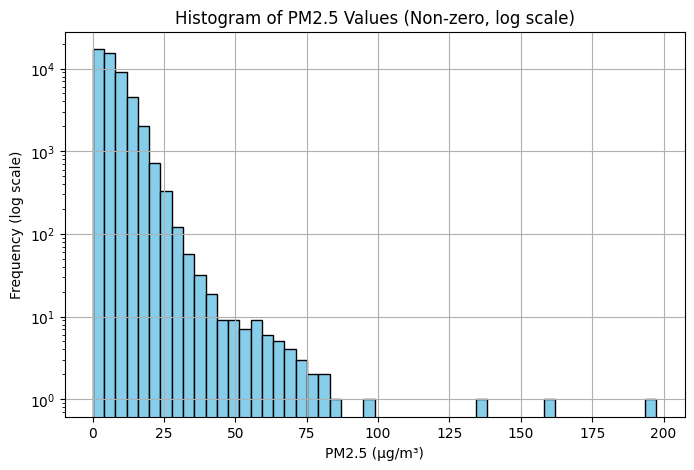

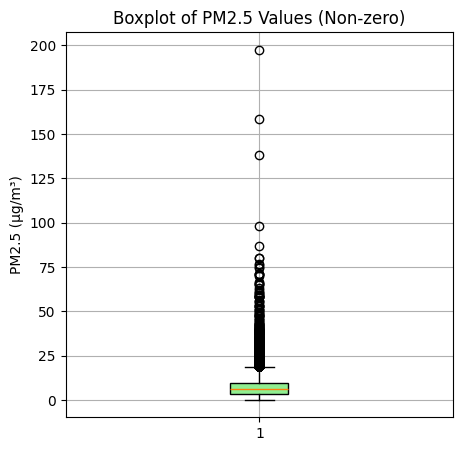

In [11]:
import matplotlib.pyplot as plt

# Filter only PM2.5 rows and remove zeros
pm25_data = airquality[airquality['pollutant'] == 'pm25']['value']
pm25_data = pm25_data[pd.to_numeric(pm25_data, errors='coerce').notnull()]  # numeric only
pm25_data = pm25_data[pm25_data > 0]  # remove zeros

# Histogram with log scale
plt.figure(figsize=(8,5))
plt.hist(pm25_data, bins=50, color='skyblue', edgecolor='black', log=True)  # log scale on y-axis
plt.title("Histogram of PM2.5 Values (Non-zero, log scale)")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()

# Boxplot of PM2.5 values
plt.figure(figsize=(5,5))
plt.boxplot(pm25_data, vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightgreen"))
plt.title("Boxplot of PM2.5 Values (Non-zero)")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.show()


## Submitting Your Work

Save you work to the path week07/week07_assignment_pandas.ipynb